In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from model_multi import LogisticRegressionMultiExpert
from data import get_dataloaders, ExpertMNIST
from l2d_functionality.l2d_loss_multi import L2D_MultiExpertLoss
from l2d_functionality.l2d_eval_multi import L2D_Eval_Multi_Expert

In [2]:
# MNIST setup
input_dim = 28 * 28
num_classes = 10
num_epochs = 12
learning_rate = 1e-5
l2_lambda = 0.0 
batch_size = 64

expert_probs = [0.99, 0.9]
num_experts = len(expert_probs)

output_dim = num_classes + num_experts

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda t: torch.flatten(t))
])

train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Generate expert labels for each expert
expert_labels_train = []
expert_labels_test = []
for prob in expert_probs:
    expert = ExpertMNIST(prob)
    expert_labels_train.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in train_raw]))
    expert_labels_test.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in test_raw]))

expert_labels_train = torch.stack(expert_labels_train, dim=1)
expert_labels_test  = torch.stack(expert_labels_test, dim=1)

train_loader, test_loader = get_dataloaders(train_raw, expert_labels_train,
                                            test_raw, expert_labels_test,
                                            batch_size=batch_size)

In [4]:
model = LogisticRegressionMultiExpert(input_dim, num_classes, num_experts, l2_lambda)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
losses = []

Epoch 1/12, Loss=4.2086
Epoch 2/12, Loss=3.3475
Epoch 3/12, Loss=2.9604
Epoch 4/12, Loss=2.7461
Epoch 5/12, Loss=2.6138
Epoch 6/12, Loss=2.5246
Epoch 7/12, Loss=2.4615
Epoch 8/12, Loss=2.4151
Epoch 9/12, Loss=2.3795
Epoch 10/12, Loss=2.3516
Epoch 11/12, Loss=2.3291
Epoch 12/12, Loss=2.3101


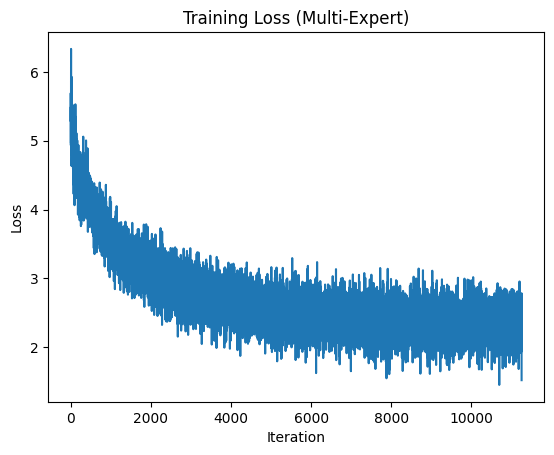

In [5]:
l2d = L2D_MultiExpertLoss(num_classes, num_experts)

for epoch in range(num_epochs):
    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)

        loss = l2d.loss_fn(outputs, labels, expert_labels_batch, param_type="softmax")
        loss += model.l2_regularization()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f"Epoch {epoch+1}/{num_epochs}, Loss={np.mean(losses[-len(train_loader):]):.4f}")

# Plot training curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss (Multi-Expert)")
plt.savefig("training_loss_multi.png")
plt.show()

=== Model Report ===
Test Accuracy of Pure Classifier: 89.19%
Test Accuracy (excluding deferrals): 93.19%
Deferral Accuracy (Experts): 83.74%
Overall Deferral Rate: 34.32%
Overall Combined Accuracy: 89.95%

=== Per-Class Report ===
Class 0: Accuracy (non-deferred) = 98.73%, Deferral Rate = 3.67%, Overall Accuracy = 95.10%
Class 1: Accuracy (non-deferred) = 96.13%, Deferral Rate = 40.79%, Overall Accuracy = 97.00%
Class 2: Accuracy (non-deferred) = 89.99%, Deferral Rate = 9.98%, Overall Accuracy = 81.01%
Class 3: Accuracy (non-deferred) = 90.06%, Deferral Rate = 66.14%, Overall Accuracy = 95.74%
Class 4: Accuracy (non-deferred) = 95.87%, Deferral Rate = 11.30%, Overall Accuracy = 85.03%
Class 5: Accuracy (non-deferred) = 81.02%, Deferral Rate = 58.07%, Overall Accuracy = 91.03%
Class 6: Accuracy (non-deferred) = 94.09%, Deferral Rate = 2.82%, Overall Accuracy = 91.44%
Class 7: Accuracy (non-deferred) = 93.61%, Deferral Rate = 60.41%, Overall Accuracy = 96.69%
Class 8: Accuracy (non-defe

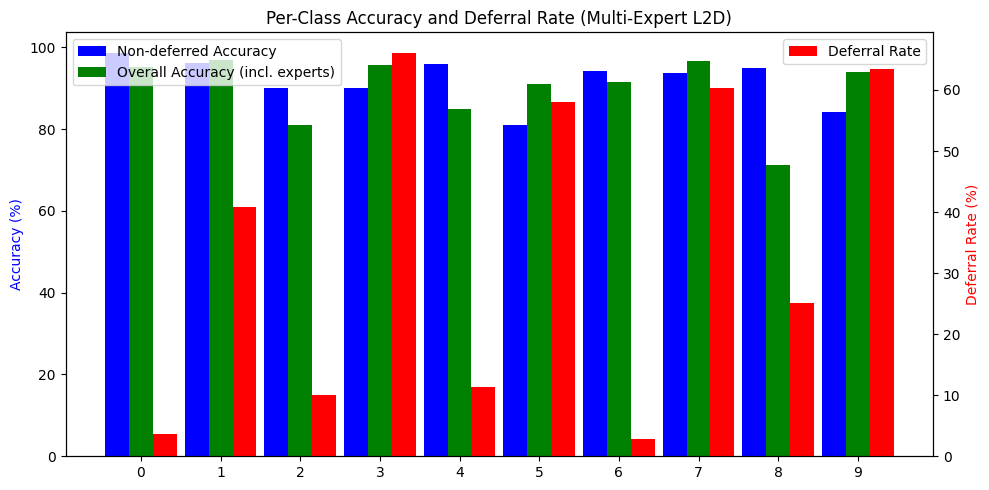

In [6]:
all_outputs = []
all_labels = []
all_expert_labels = []

with torch.no_grad():
    for images, labels, expert_labels in test_loader:
        outputs = model(images)
        all_outputs.append(outputs)
        all_labels.append(labels)
        all_expert_labels.append(expert_labels)

all_outputs = torch.cat(all_outputs, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_expert_labels = torch.cat(all_expert_labels, dim=0)

l2d_eval = L2D_Eval_Multi_Expert(num_classes, all_outputs, all_labels, all_expert_labels)

print("=== Model Report ===")
model_report = l2d_eval.model_report()

print("\n=== Per-Class Report ===")
per_class_report = l2d_eval.per_class_report()

print("\n=== Expert Report ===")
expert_report = l2d_eval.expert_report()

l2d_eval.visualize_per_class_metrics("per_class_metrics_multi.png")
